# 06 - Player Localization

## Obiettivo

Dopo aver completato la player detection, il Multi-Object Tracking e la calibrazione geometrica del campo, questa fase combina le tracce prodotte da RF-DETR + ByteTrack con la matrice di omografia stimata nel notebook precedente.

Per ogni osservazione di un giocatore viene utilizzato il punto bottom-center della bounding box come approssimazione del punto di contatto con il parquet.

La pipeline considerata è:

RF-DETR Nano
→ ByteTrack
→ bounding box + track ID
→ bottom-center
→ omografia
→ coordinate metriche sul campo.

L'obiettivo è ottenere una struttura temporale del tipo:

(frame, time, track_id, pixel_x, pixel_y, court_x, court_y)

che costituisce l'input per la successiva ricostruzione delle traiettorie e per le analisi spaziali.

La calibrazione utilizzata in questa baseline è stata stimata manualmente su un singolo frame. Di conseguenza, le coordinate ottenute sono affidabili soltanto finché la geometria della camera rimane sufficientemente simile a quella del frame di calibrazione.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/basketball-thesis"
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

SPORTSMOT_ROOT = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
)

SEQUENCE_DIR = (
    SPORTSMOT_ROOT
    / "val"
    / SEQUENCE_NAME
)

FRAMES_DIR = (
    SEQUENCE_DIR
    / "img1"
)

TRACKING_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "bytetrack_baseline"
)

HOMOGRAPHY_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "court_homography_baseline"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "player_localization"
    / SEQUENCE_NAME
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Sequence:", SEQUENCE_DIR)
print("Tracking:", TRACKING_DIR)
print("Homography:", HOMOGRAPHY_DIR)
print("Output:", OUTPUT_DIR)

Sequence: /content/drive/MyDrive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001
Tracking: /content/drive/MyDrive/basketball-thesis/experiments/bytetrack_baseline
Homography: /content/drive/MyDrive/basketball-thesis/experiments/court_homography_baseline
Output: /content/drive/MyDrive/basketball-thesis/experiments/player_localization/v_00HRwkvvjtQ_c001


In [9]:
TRACKS_FILE = (
    TRACKING_DIR
    / f"{SEQUENCE_NAME}_tracks.csv"
)

H_FILE = (
    HOMOGRAPHY_DIR
    / f"{SEQUENCE_NAME}_homography.npy"
)

POINTS_FILE = (
    HOMOGRAPHY_DIR
    / f"{SEQUENCE_NAME}_points.npz"
)

print("Tracks:", TRACKS_FILE.exists())
print("Homography:", H_FILE.exists())
print("Points:", POINTS_FILE.exists())

assert TRACKS_FILE.exists(), (
    f"Tracking CSV non trovato: {TRACKS_FILE}"
)

assert H_FILE.exists(), (
    f"Homography non trovata: {H_FILE}"
)

assert POINTS_FILE.exists(), (
    f"Punti di calibrazione non trovati: {POINTS_FILE}"
)

Tracks: True
Homography: True
Points: True


In [10]:
tracks_df = pd.read_csv(TRACKS_FILE)

print("Numero osservazioni:", len(tracks_df))
print("Numero track ID:", tracks_df["track_id"].nunique())

tracks_df.head()

Numero osservazioni: 10911
Numero track ID: 27


,frame,time,track_id,confidence,x1,y1,x2,y2
0,2,0.04,0,0.946324,434.150208,268.251007,560.730225,436.969055
1,2,0.04,1,0.918906,973.851013,390.865112,1050.417969,604.696655
2,2,0.04,2,0.847886,636.885437,416.111542,768.735291,625.620422
3,2,0.04,3,0.852696,990.499023,290.476685,1053.694336,497.540070
4,2,0.04,4,0.760169,652.945557,272.642029,758.719788,433.214172


In [11]:
required_columns = [
    "frame",
    "time",
    "track_id",
    "confidence",
    "x1",
    "y1",
    "x2",
    "y2",
]

missing_columns = [
    col
    for col in required_columns
    if col not in tracks_df.columns
]

print(
    "Colonne mancanti:",
    missing_columns
)

assert not missing_columns, (
    f"Colonne mancanti nel tracking CSV: {missing_columns}"
)

print(
    "Range frame:",
    tracks_df["frame"].min(),
    "→",
    tracks_df["frame"].max()
)

print(
    "Track ID unici:",
    tracks_df["track_id"].nunique()
)

Colonne mancanti: []
Range frame: 2 → 1162
Track ID unici: 27


## Caricamento dell'omografia

In [12]:
H = np.load(
    H_FILE
)

assert H.shape == (3, 3), (
    f"Shape H non valida: {H.shape}"
)

print("Matrice H:")
print(H)

print(
    "\nShape:",
    H.shape
)

Matrice H:
[[ 2.04808010e-02  1.48297833e-02  6.45205375e+00]
 [ 1.95903487e-03  5.67150834e-02 -1.19672047e+01]
 [ 7.18827304e-05  1.07521992e-03  1.00000000e+00]]

Shape: (3, 3)


## Caricamento dei punti e dei metadati di calibrazione

In [13]:
points_data = np.load(
    POINTS_FILE,
    allow_pickle=True,
)

image_points = points_data[
    "image_points"
]

court_points = points_data[
    "court_points"
]

CALIBRATION_FRAME = int(
    points_data["frame_number"]
)

COURT_LENGTH = float(
    points_data["court_length"]
)

COURT_WIDTH = float(
    points_data["court_width"]
)

COURT_UNIT = str(
    points_data["unit"]
)

print("Calibration frame:", CALIBRATION_FRAME)
print("Court length:", COURT_LENGTH)
print("Court width:", COURT_WIDTH)
print("Unit:", COURT_UNIT)

print("\nImage points:")
print(image_points)

print("\nCourt points:")
print(court_points)

Calibration frame: 100
Court length: 28.6512
Court width: 15.24
Unit: meters

Image points:
[[ 410.  197.]
 [ 415.  339.]
 [ 418.  448.]
 [ 425.  666.]
 [1039.  320.]
 [1091.  430.]]

Court points:
[[14.325601  0.      ]
 [14.325601  5.7912  ]
 [14.325601  9.4488  ]
 [14.325601 15.24    ]
 [22.86      5.7912  ]
 [22.86      9.4488  ]]


## Calcolo del punto bottom-center

Per ogni bounding box, la posizione del giocatore sul parquet viene approssimata tramite il punto bottom-center:

x = (x1 + x2) / 2  
y = y2

Questa scelta è preferibile al centro geometrico della bounding box perché rappresenta più direttamente la zona di contatto del giocatore con il piano del campo.

In [14]:
def bbox_bottom_center(
    x1,
    y1,
    x2,
    y2,
):
    x = (x1 + x2) / 2.0
    y = y2

    return x, y

### Calcolo del bottom-center per tutte le osservazioni

In [15]:
tracks_df["pixel_x"] = (
    tracks_df["x1"]
    + tracks_df["x2"]
) / 2.0

tracks_df["pixel_y"] = (
    tracks_df["y2"]
)

display(
    tracks_df[
        [
            "frame",
            "time",
            "track_id",
            "pixel_x",
            "pixel_y",
        ]
    ].head()
)

,frame,time,track_id,pixel_x,pixel_y
0,2,0.04,0,497.440216,436.969055
1,2,0.04,1,1012.134491,604.696655
2,2,0.04,2,702.810364,625.620422
3,2,0.04,3,1022.096680,497.540070
4,2,0.04,4,705.832672,433.214172


## Trasformazione immagine → campo
Funzione di omografia

In [16]:
def image_to_court(
    x,
    y,
    H,
):

    point = np.array(
        [[[x, y]]],
        dtype=np.float32,
    )

    projected = cv2.perspectiveTransform(
        point,
        H,
    )

    court_x, court_y = projected[0][0]

    return float(court_x), float(court_y)

### Sanity check sul frame di calibrazione

In [17]:
calibration_tracks = tracks_df[
    tracks_df["frame"] == CALIBRATION_FRAME
].copy()

assert not calibration_tracks.empty, (
    f"Nessuna track nel frame {CALIBRATION_FRAME}"
)

example = calibration_tracks.iloc[0]

court_x, court_y = image_to_court(
    example["pixel_x"],
    example["pixel_y"],
    H,
)

print(
    "Track ID:",
    int(example["track_id"])
)

print(
    "Pixel:",
    (
        round(example["pixel_x"], 2),
        round(example["pixel_y"], 2),
    )
)

print(
    "Campo [m]:",
    (
        round(court_x, 3),
        round(court_y, 3),
    )
)

Track ID: 0
Pixel: (np.float64(906.89), np.float64(393.31))
Campo [m]: (20.737, 8.142)


## Proiezione di tutte le osservazioni

La matrice di omografia viene applicata al bottom-center di ogni bounding box.

L'output della trasformazione contiene, per ogni osservazione temporale, una coppia di coordinate metriche `(court_x, court_y)`.

È importante sottolineare che questa baseline utilizza una singola matrice H stimata sul frame di calibrazione. In presenza di movimento della camera, le coordinate ottenute nei frame temporalmente distanti possono quindi diventare inaccurate.

In [18]:
pixel_points = tracks_df[
    [
        "pixel_x",
        "pixel_y",
    ]
].to_numpy(
    dtype=np.float32
)

pixel_points_cv = (
    pixel_points
    .reshape(-1, 1, 2)
)

court_positions = (
    cv2.perspectiveTransform(
        pixel_points_cv,
        H,
    )
    .reshape(-1, 2)
)

tracks_df["court_x"] = (
    court_positions[:, 0]
)

tracks_df["court_y"] = (
    court_positions[:, 1]
)

display(
    tracks_df[
        [
            "frame",
            "time",
            "track_id",
            "pixel_x",
            "pixel_y",
            "court_x",
            "court_y",
        ]
    ].head()
)

,frame,time,track_id,pixel_x,pixel_y,court_x,court_y
0,2,0.04,0,497.440216,436.969055,15.356175,9.159191
1,2,0.04,1,1012.134491,604.696655,20.980978,14.110223
2,2,0.04,2,702.810364,625.620422,17.481428,14.445071
3,2,0.04,3,1022.096680,497.540070,21.613432,11.348380
4,2,0.04,4,705.832672,433.214172,18.022991,9.221877


## Controllo di validità delle coordinate

In [19]:
tracks_df["inside_court"] = (
    (tracks_df["court_x"] >= 0)
    & (tracks_df["court_x"] <= COURT_LENGTH)
    & (tracks_df["court_y"] >= 0)
    & (tracks_df["court_y"] <= COURT_WIDTH)
)

inside_count = int(
    tracks_df["inside_court"].sum()
)

outside_count = int(
    (~tracks_df["inside_court"]).sum()
)

inside_ratio = (
    tracks_df["inside_court"].mean()
)

print(
    "Osservazioni totali:",
    len(tracks_df)
)

print(
    "Dentro il campo:",
    inside_count
)

print(
    "Fuori dal campo:",
    outside_count
)

print(
    "Percentuale inside:",
    f"{inside_ratio * 100:.2f}%"
)

Osservazioni totali: 10911
Dentro il campo: 10651
Fuori dal campo: 260
Percentuale inside: 97.62%


controllo NaN/infinito

In [20]:
finite_mask = np.isfinite(
    tracks_df[
        ["court_x", "court_y"]
    ].to_numpy()
).all(axis=1)

print(
    "Coordinate finite:",
    finite_mask.sum(),
    "/",
    len(tracks_df)
)

assert finite_mask.all(), (
    "Sono presenti coordinate non finite."
)

Coordinate finite: 10911 / 10911


## Verifica visiva sul frame di calibrazione

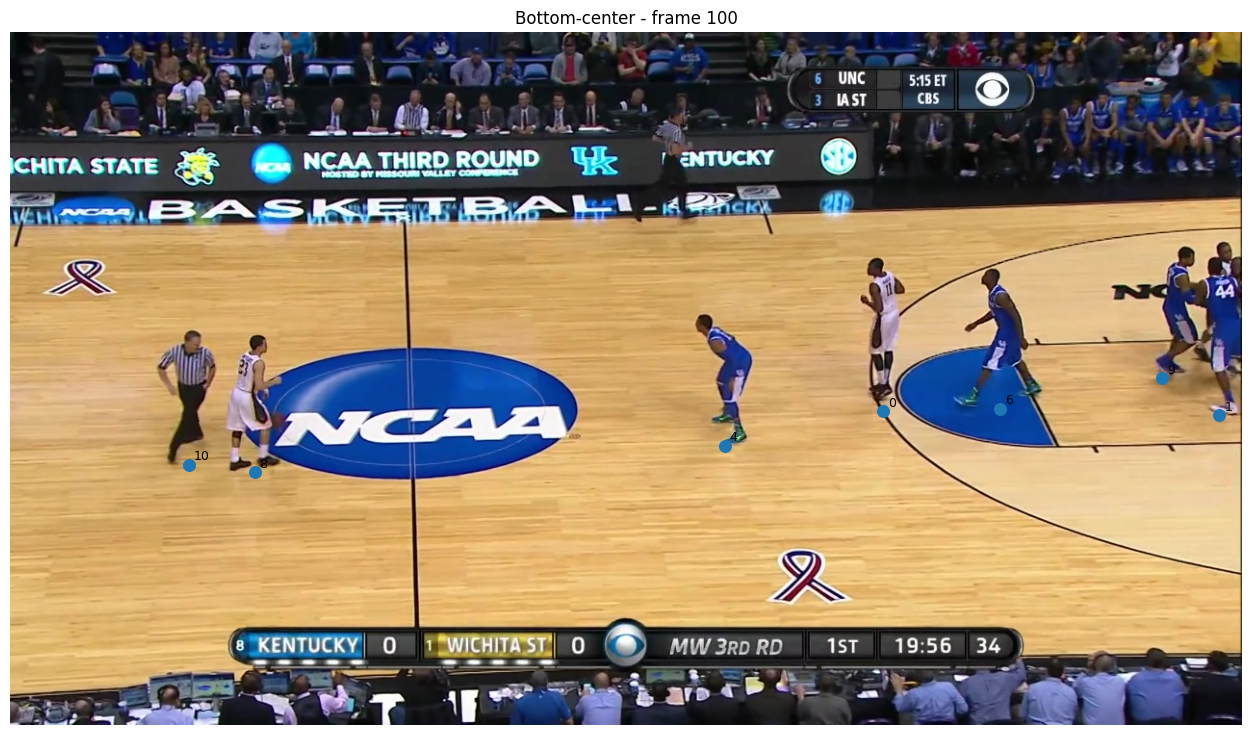

In [21]:
frame_path = (
    FRAMES_DIR
    / f"{CALIBRATION_FRAME:06d}.jpg"
)

frame_bgr = cv2.imread(
    str(frame_path)
)

assert frame_bgr is not None

frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB,
)

frame_df = tracks_df[
    tracks_df["frame"]
    == CALIBRATION_FRAME
].copy()

plt.figure(
    figsize=(16, 9)
)

plt.imshow(frame_rgb)

plt.scatter(
    frame_df["pixel_x"],
    frame_df["pixel_y"],
    s=70,
)

for _, row in frame_df.iterrows():

    plt.text(
        row["pixel_x"] + 5,
        row["pixel_y"] - 5,
        str(int(row["track_id"])),
        fontsize=9,
    )

plt.title(
    f"Bottom-center - frame {CALIBRATION_FRAME}"
)

plt.axis("off")
plt.show()

stessa situazione vista top-down

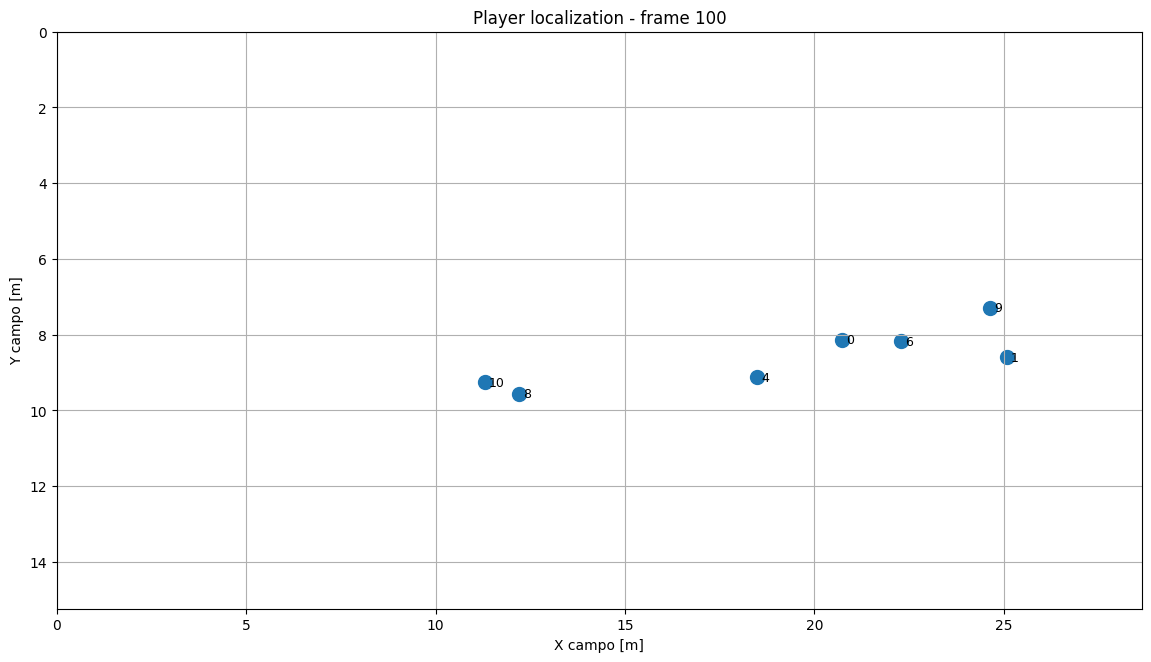

In [22]:
plt.figure(
    figsize=(14, 7.5)
)

plt.xlim(
    0,
    COURT_LENGTH,
)

plt.ylim(
    COURT_WIDTH,
    0,
)

plt.gca().set_aspect(
    "equal"
)

plt.scatter(
    frame_df["court_x"],
    frame_df["court_y"],
    s=100,
)

for _, row in frame_df.iterrows():

    plt.text(
        row["court_x"] + 0.1,
        row["court_y"] + 0.1,
        str(int(row["track_id"])),
        fontsize=9,
    )

plt.xlabel(
    "X campo [m]"
)

plt.ylabel(
    "Y campo [m]"
)

plt.title(
    f"Player localization - frame {CALIBRATION_FRAME}"
)

plt.grid()

plt.show()

selezione output

In [23]:
localization_columns = [
    "frame",
    "time",
    "track_id",
    "confidence",
    "pixel_x",giocato
    "pixel_y",
    "court_x",
    "court_y",
    "inside_court",
]

localized_df = (
    tracks_df[
        localization_columns
    ]
    .copy()
)

display(
    localized_df.head()
)

,frame,time,track_id,confidence,pixel_x,pixel_y,court_x,court_y,inside_court
0,2,0.04,0,0.946324,497.440216,436.969055,15.356175,9.159191,True
1,2,0.04,1,0.918906,1012.134491,604.696655,20.980978,14.110223,True
2,2,0.04,2,0.847886,702.810364,625.620422,17.481428,14.445071,True
3,2,0.04,3,0.852696,1022.096680,497.540070,21.613432,11.348380,True
4,2,0.04,4,0.760169,705.832672,433.214172,18.022991,9.221877,True


salva il CSV

In [24]:
LOCALIZED_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_localized_players.csv"
)

localized_df.to_csv(
    LOCALIZED_CSV,
    index=False,
)

print(
    "Salvato:"
)

print(
    LOCALIZED_CSV
)

Salvato:
/content/drive/MyDrive/basketball-thesis/experiments/player_localization/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_localized_players.csv


riepilogo per track

In [25]:
track_summary = (
    localized_df
    .groupby("track_id")
    .agg(
        observations=(
            "frame",
            "count",
        ),
        first_frame=(
            "frame",
            "min",
        ),
        last_frame=(
            "frame",
            "max",
        ),
        mean_x=(
            "court_x",
            "mean",
        ),
        mean_y=(
            "court_y",
            "mean",
        ),
        inside_ratio=(
            "inside_court",
            "mean",
        ),
    )
    .reset_index()
)

display(
    track_summary
)

,track_id,observations,first_frame,last_frame,mean_x,mean_y,inside_ratio
0,0,1151,2,1162,17.097910,11.427017,0.979149
1,1,780,2,818,18.576479,3.871068,0.865385
2,2,74,2,75,20.978636,12.469759,1.000000
3,3,76,2,78,22.148478,9.378033,1.000000
4,4,1144,2,1162,17.599253,7.439928,0.966783
5,5,62,3,68,19.583553,8.093105,1.000000
6,6,896,3,909,17.645092,10.191115,1.000000
7,7,50,5,54,21.433487,12.779698,1.000000
8,8,807,17,827,11.999626,5.747966,1.000000
9,9,236,18,275,19.656023,7.293026,1.000000


salva summary

In [26]:
SUMMARY_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_localization_summary.csv"
)

track_summary.to_csv(
    SUMMARY_CSV,
    index=False,
)

print(
    "Summary salvato:"
)

print(
    SUMMARY_CSV
)

Summary salvato:
/content/drive/MyDrive/basketball-thesis/experiments/player_localization/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_localization_summary.csv


grafico preliminare delle posizioni

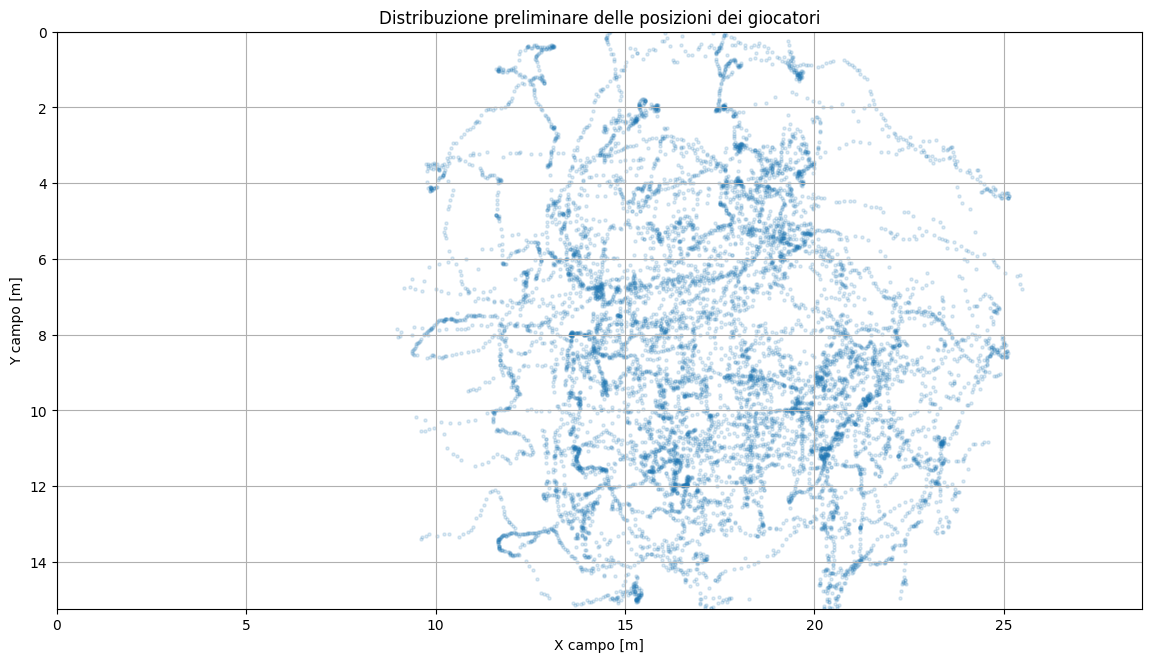

In [27]:
valid_positions = localized_df[
    localized_df["inside_court"]
].copy()

plt.figure(
    figsize=(14, 7.5)
)

plt.scatter(
    valid_positions["court_x"],
    valid_positions["court_y"],
    s=5,
    alpha=0.15,
)

plt.xlim(
    0,
    COURT_LENGTH,
)

plt.ylim(
    COURT_WIDTH,
    0,
)

plt.gca().set_aspect(
    "equal"
)

plt.xlabel(
    "X campo [m]"
)

plt.ylabel(
    "Y campo [m]"
)

plt.title(
    "Distribuzione preliminare delle posizioni dei track"
)

plt.grid()
plt.show()

### False positive semantici

La pipeline di tracking può includere soggetti presenti sul parquet che non appartengono alle due squadre, come gli arbitri.

Nel frame di calibrazione, ad esempio, uno dei track ID associati dal sistema corrisponde visivamente a un arbitro.

Dal punto di vista geometrico, la localizzazione di tale soggetto risulta comunque corretta, poiché l'omografia trasforma qualsiasi punto immagine sul piano del campo.

Tuttavia, ai fini delle successive analisi tattiche, heatmap e statistiche di squadra, sarà necessario distinguere i giocatori dagli arbitri e dagli altri soggetti rilevati.

Questa fase verrà affrontata tramite un modulo di classificazione semantica dei track.

## Limiti della baseline

La localizzazione ottenuta in questo notebook utilizza una singola matrice di omografia, stimata manualmente sul frame di calibrazione.

Questa assunzione è valida soltanto quando la relazione geometrica tra camera e campo rimane sufficientemente stabile.

Nei video broadcast di basket sono frequenti:

- pan della telecamera;
- zoom;
- cambi di inquadratura;
- variazioni della porzione di campo visibile.

In presenza di tali fenomeni, la stessa matrice H può produrre coordinate progressivamente inaccurate nei frame temporalmente distanti da quello utilizzato per la calibrazione.

Per questo motivo viene mantenuto il campo `inside_court`, che permette una prima analisi diagnostica delle proiezioni geometricamente non plausibili.

La baseline manuale costituisce quindi un primo esperimento per verificare l'intera catena:

tracking → bottom-center → omografia → coordinate sul campo.

Una successiva evoluzione potrà utilizzare court keypoint detection e omografie dinamiche per aggiornare la calibrazione nel tempo.

# Risultati della Player Localization

La pipeline RF-DETR Nano + ByteTrack è stata collegata alla calibrazione geometrica del campo.

Per ogni osservazione temporale è stato calcolato il punto bottom-center della bounding box e successivamente trasformato tramite la matrice di omografia.

L'output finale contiene:

- frame;
- timestamp;
- track ID;
- confidence;
- coordinate pixel;
- coordinate metriche sul campo;
- indicatore di validità rispetto ai limiti geometrici del campo.

Il file risultante:

`v_00HRwkvvjtQ_c001_localized_players.csv`

costituisce l'input della successiva fase di trajectory analysis.
